In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 2. Load the Data 
df_reviews = pd.read_csv('Processed_Reviews.csv')

# 3. Pre-processing: Use only lemmatized column 
# Ensure no missing values in the target column
df_reviews = df_reviews.dropna(subset=['lemmatized', 'label'])

# 4. Vectorization 
tfidf = TfidfVectorizer() 
X_rev = tfidf.fit_transform(df_reviews['lemmatized']) 
y_rev = df_reviews['label'] 

# 5. Model Training 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42) 
review_model = MultinomialNB().fit(X_train_r, y_train_r) 

# 6. Evaluation 
y_pred_r = review_model.predict(X_test_r) 
print("Exercise Model Performance:") 
print(classification_report(y_test_r, y_pred_r))
print("Accuracy:", accuracy_score(y_test_r, y_pred_r)) 

Exercise Model Performance:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Accuracy: 1.0


C:\Users\nabie\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\nabie\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


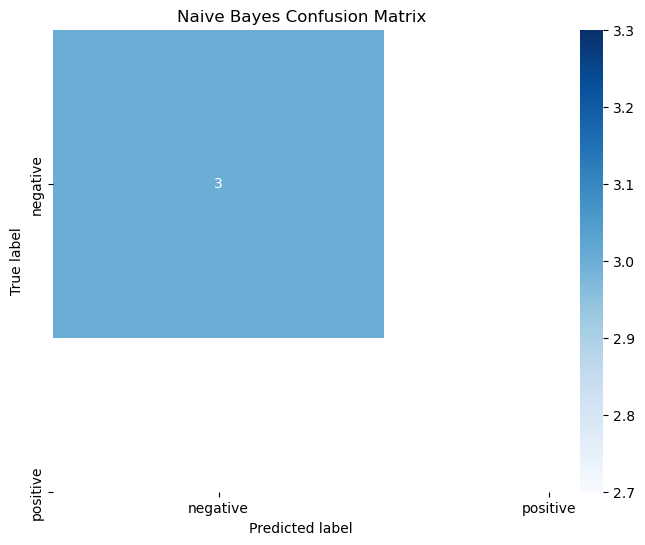

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Naive Bayes Error Rate: 0.00


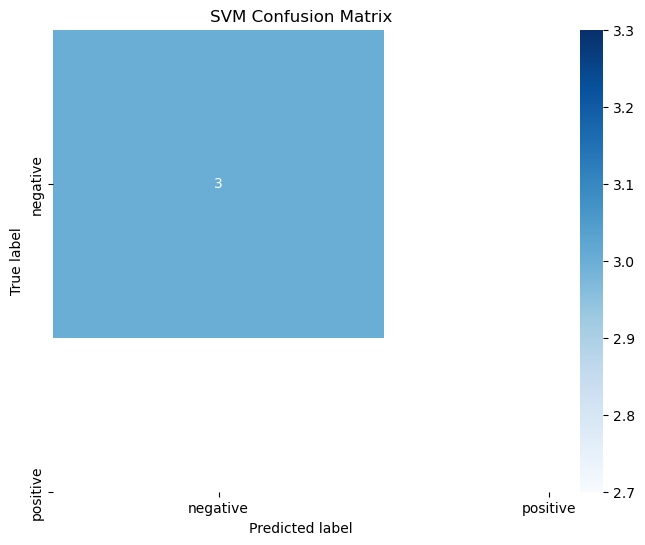


SVM Classifier Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

SVM Error Rate: 0.00


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Function
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

# Model Training (Naive Bayes & SVM)

# Train Naive Bayes
nb_model = MultinomialNB().fit(X_train_r, y_train_r)

# Train SVM (as mentioned in instructions)
svm_model = SVC(kernel='linear').fit(X_train_r, y_train_r)

# Evaluation 

# Naive Bayes Evaluation 
y_pred_nb = nb_model.predict(X_test_r)
nb_cm = confusion_matrix(y_test_r, y_pred_nb)
nb_report = classification_report(y_test_r, y_pred_nb)
nb_error_rate = 1 - accuracy_score(y_test_r, y_pred_nb) 

# SVM Evaluation 
y_pred_svm = svm_model.predict(X_test_r)
svm_cm = confusion_matrix(y_test_r, y_pred_svm)
svm_report = classification_report(y_test_r, y_pred_svm)
svm_error_rate = 1 - accuracy_score(y_test_r, y_pred_svm) 

# Display Results

# Plot and Print for Naive Bayes 
plot_confusion_matrix(nb_cm, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report)
print(f"Naive Bayes Error Rate: {nb_error_rate:.2f}")

# Plot and Print for SVM 
plot_confusion_matrix(svm_cm, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report)
print(f"SVM Error Rate: {svm_error_rate:.2f}")